# Softmax Classifier on CIFAR-10

This notebook demonstrates a from-scratch implementation of a **multiclass linear classifier trained with the softmax loss** on CIFAR-10.

## Goals
- load and inspect CIFAR-10
- preprocess images into row vectors with a bias term
- implement the softmax loss in both naive and vectorized forms
- verify gradients numerically
- train the classifier with SGD
- tune hyperparameters on a validation set
- visualize the learned class templates

## Related source files
- `src/models/softmax.py`
- `src/models/linear_classifier.py`
- `src/utils/data.py`
- `src/utils/gradient_check.py`

This notebook is written in the same repo-friendly style as the adapted k-NN demo: it is meant to live in `demos/`, while reusable code lives in `src/`.


## 0. What is softmax classification?

A linear softmax classifier computes class scores
$$s = xW,$$
where $x \in \mathbf{R}^D$ is one input row vector and $W \in \mathbf{R}^{D \times C}$ is the weight matrix.

These scores are turned into probabilities by
$$p_j = \frac{e^{s_j}}{\sum_k e^{s_k}},$$
and the loss for the correct class $y$ is
$$L = -\log p_y.$$

So the model is still linear in the input, but the softmax loss encourages the correct class score to be large relative to the others.


## 1. Setup

The path adjustment below lets the notebook import from the repository root when it is run locally.

The import block first tries a `src/...` layout and then falls back to the original `cs231n/...` layout, so it is convenient while you are still transitioning code.


In [8]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import random
import time
import tarfile
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

from src.utils.data import load_CIFAR10
from src.models.softmax import softmax_loss_naive, softmax_loss_vectorized
from src.models.linear_classifier import Softmax
from src.utils.gradient_check import grad_check_sparse
# try:
#     from src.utils.data import load_CIFAR10
#     from src.models.softmax import softmax_loss_naive, softmax_loss_vectorized
#     from src.models.linear_classifier import Softmax
#     from src.utils.gradient_check import grad_check_sparse
#     SOURCE_LAYOUT = "src"
# except ImportError:
#     from cs231n.data_utils import load_CIFAR10
#     from cs231n.classifiers.softmax import softmax_loss_naive, softmax_loss_vectorized
#     from cs231n.classifiers import Softmax
#     from cs231n.gradient_check import grad_check_sparse
#     SOURCE_LAYOUT = "cs231n"

# print(f"Using source layout: {SOURCE_LAYOUT}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load CIFAR-10

We first load the raw CIFAR-10 data. Each image has shape `(32, 32, 3)`.
If the dataset is missing, the notebook downloads it into `data/`.


In [9]:
# Update this path if your local data directory is different.
cifar10_dir = repo_root / "data" / "cifar-10-batches-py"

if not cifar10_dir.exists():
    print("CIFAR-10 dataset not found. Downloading...")

    data_dir = repo_root / "data"
    data_dir.mkdir(parents=True, exist_ok=True)

    url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
    archive_path = data_dir / "cifar-10-python.tar.gz"

    urllib.request.urlretrieve(url, archive_path)

    print("Extracting dataset...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_dir)

    print("Download complete.")

for name in ["X_train", "y_train", "X_test", "y_test"]:
    if name in globals():
        del globals()[name]

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print("Training data shape: ", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:     ", X_test.shape)
print("Test labels shape:   ", y_test.shape)


Training data shape:  (50000, 32, 32, 3)
Training labels shape: (50000,)
Test data shape:      (10000, 32, 32, 3)
Test labels shape:    (10000,)


## 3. Visualize a few examples

A quick visualization helps confirm both the data format and the variety across classes.


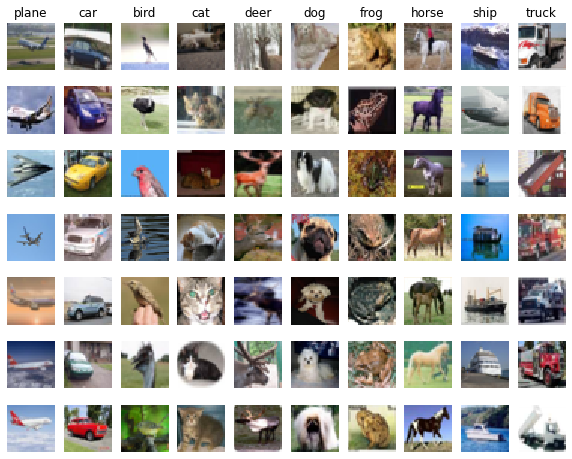

In [10]:
classes = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
num_classes = len(classes)
samples_per_class = 7

for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype("uint8"))
        plt.axis("off")
        if i == 0:
            plt.title(cls)

plt.show()


## 4. Split and preprocess the data

We create:
- a training set,
- a validation set,
- a small development set for fast gradient checks,
- and a test set.

Then we:
1. flatten each image into a row vector,
2. subtract the mean image,
3. append a column of ones for the bias trick.


Train data shape:       (49000, 32, 32, 3)
Train labels shape:     (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels:      (1000,)
Test data shape:        (1000, 32, 32, 3)
Test labels shape:      (1000,)
Dev data shape:         (500, 32, 32, 3)

After flattening:
X_train: (49000, 3072)
X_val:   (1000, 3072)
X_test:  (1000, 3072)
X_dev:   (500, 3072)

First 10 entries of mean image: [130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


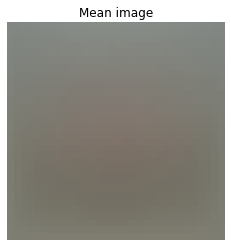


After mean subtraction and bias trick:
X_train: (49000, 3073)
X_val:   (1000, 3073)
X_test:  (1000, 3073)
X_dev:   (500, 3073)


In [11]:
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

mask = list(range(num_training, num_training + num_validation))
X_val = X_train[mask]
y_val = y_train[mask]

mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]

mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

print("Train data shape:      ", X_train.shape)
print("Train labels shape:    ", y_train.shape)
print("Validation data shape: ", X_val.shape)
print("Validation labels:     ", y_val.shape)
print("Test data shape:       ", X_test.shape)
print("Test labels shape:     ", y_test.shape)
print("Dev data shape:        ", X_dev.shape)

X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

print("\nAfter flattening:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("X_dev:  ", X_dev.shape)

mean_image = np.mean(X_train, axis=0)
print("\nFirst 10 entries of mean image:", mean_image[:10])

plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape(32, 32, 3).astype("uint8"))
plt.title("Mean image")
plt.axis("off")
plt.show()

X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image
X_dev = X_dev - mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print("\nAfter mean subtraction and bias trick:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("X_dev:  ", X_dev.shape)


## 5. Evaluate the naive softmax loss

We start with a random weight matrix of very small values and evaluate the naive implementation.


In [12]:
W = np.random.randn(X_train.shape[1], 10) * 1e-4

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e-6)
print("loss: %f" % loss)
print("sanity check: %f" % (-np.log(0.1)))


loss: 2.381208
sanity check: 2.302585


### Why should the initial loss be close to $-\log(0.1)$?

With very small random weights, the class scores are all close to each other, so after softmax each class gets probability close to $0.1$.

Therefore the correct-class loss for one example is approximately
$$-\log(0.1).$$

This is the multiclass analogue of saying that an untrained classifier is close to making uniform predictions.


## 6. Gradient check for the naive implementation

After you implement the gradient in `softmax_loss_naive`, the analytic gradient should match the numerical gradient very closely.


In [13]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)


numerical: 0.998671 analytic: 0.998671, relative error: 1.922341e-08
numerical: 1.031482 analytic: 1.031482, relative error: 4.538931e-08
numerical: -0.289169 analytic: -0.289169, relative error: 1.617086e-07
numerical: -0.680725 analytic: -0.680725, relative error: 3.848713e-08
numerical: -2.011215 analytic: -2.011215, relative error: 2.018406e-09
numerical: 1.617899 analytic: 1.617898, relative error: 3.868309e-08
numerical: 3.951851 analytic: 3.951851, relative error: 1.807121e-08
numerical: -1.288873 analytic: -1.288873, relative error: 1.412817e-09
numerical: 0.401164 analytic: 0.401164, relative error: 1.024867e-07
numerical: 3.056426 analytic: 3.056426, relative error: 2.185470e-08
numerical: 2.359336 analytic: 2.359336, relative error: 3.461875e-09
numerical: 1.633966 analytic: 1.633965, relative error: 2.559325e-08
numerical: 0.488078 analytic: 0.488078, relative error: 4.789466e-08
numerical: 0.535911 analytic: 0.535911, relative error: 1.117361e-08
numerical: 0.491843 analyt

### Note on gradient checking: softmax versus SVM

A useful conceptual distinction is this:

- The **softmax loss** is smooth, so numerical gradient checking is usually extremely stable.
- The **multiclass SVM hinge loss** is not differentiable at margin boundaries, because of the $\max(0, \cdot)$ term.

So if an SVM gradient check occasionally shows a discrepancy in one coordinate, that can happen simply because the finite-difference probe crossed a kink. This is usually **not** a bug by itself.

A one-dimensional toy example is
$$L(w) = \max(0, w).$$
At $w = 0$, the derivative is not uniquely defined, so a symmetric finite-difference estimate can behave awkwardly.

In the multiclass SVM setting, the same issue occurs when some margin
$$s_j - s_y + \Delta$$
is very close to $0$.

If the margin parameter $\Delta$ is changed, then the locations of those kink boundaries shift. In practice, a larger margin can make it more likely that some sample lies near a hinge boundary, so such rare gradient-check mismatches may appear a bit more often.


## 7. Compare naive and vectorized loss

The vectorized implementation should produce the same loss, but much faster.


In [14]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 5e-6)
toc = time.time()
print("Naive loss:      %e computed in %fs" % (loss_naive, toc - tic))

tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 5e-6)
toc = time.time()
print("Vectorized loss: %e computed in %fs" % (loss_vectorized, toc - tic))

print("difference: %f" % (loss_naive - loss_vectorized))


Naive loss:      2.381208e+00 computed in 0.078947s
Vectorized loss: 2.381208e+00 computed in 0.009706s
difference: 0.000000


## 8. Compare naive and vectorized gradients

Now we compare the gradients using the Frobenius norm.


In [15]:
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 5e-6)
toc = time.time()
print("Naive gradient computed in %fs" % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 5e-6)
toc = time.time()
print("Vectorized gradient computed in %fs" % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord="fro")
print("gradient difference: %f" % difference)


Naive gradient computed in 0.071398s
Vectorized gradient computed in 0.003812s
gradient difference: 0.000000


## 9. Train the classifier with SGD

Once the loss and gradient are correct, we can train the linear classifier by stochastic gradient descent.

The implementation for this part belongs in `src/models/linear_classifier.py` (or the original `cs231n/classifiers/linear_classifier.py` if you are still using the assignment layout).


In [16]:
softmax = Softmax()

tic = time.time()
loss_hist = softmax.train(
    X_train,
    y_train,
    learning_rate=1e-7,
    reg=2.5e4,
    num_iters=1500,
    verbose=True,
)
toc = time.time()

print("Training took %fs" % (toc - tic))


iteration 0 / 1500: loss 779.445520
iteration 100 / 1500: loss 285.975648
iteration 200 / 1500: loss 106.008689
iteration 300 / 1500: loss 40.116929
iteration 400 / 1500: loss 16.062928
iteration 500 / 1500: loss 7.222055
iteration 600 / 1500: loss 3.995073
iteration 700 / 1500: loss 2.756730
iteration 800 / 1500: loss 2.330360
iteration 900 / 1500: loss 2.209098
iteration 1000 / 1500: loss 2.129821
iteration 1100 / 1500: loss 2.110624
iteration 1200 / 1500: loss 2.103439
iteration 1300 / 1500: loss 2.067254
iteration 1400 / 1500: loss 2.100744
Training took 3.123118s


## 10. Plot the loss history

A steadily decreasing loss curve is a basic sanity check for SGD.


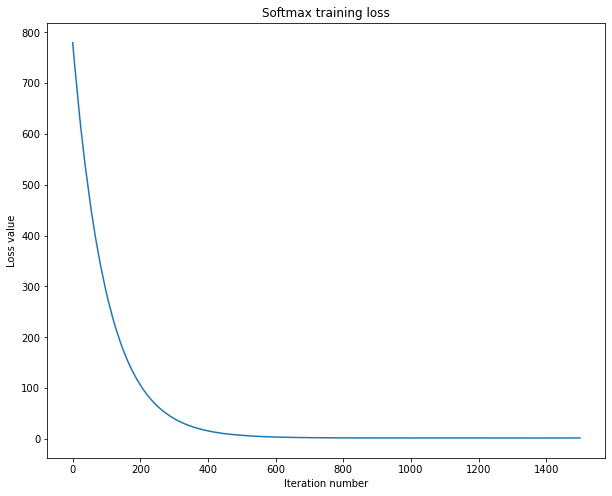

In [17]:
plt.plot(loss_hist)
plt.xlabel("Iteration number")
plt.ylabel("Loss value")
plt.title("Softmax training loss")
plt.show()


## 11. Evaluate on the training and validation sets

A validation accuracy around the low-to-mid 30% range is a reasonable first target here.


In [18]:
y_train_pred = softmax.predict(X_train)
train_accuracy = np.mean(y_train == y_train_pred)
print("training accuracy:   %f" % train_accuracy)

y_val_pred = softmax.predict(X_val)
val_accuracy = np.mean(y_val == y_val_pred)
print("validation accuracy: %f" % val_accuracy)

artifacts_dir = repo_root / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

softmax.save(str(artifacts_dir / "softmax.npy"))
print(f"Saved model to {artifacts_dir / 'softmax.npy'}")


training accuracy:   0.331571
validation accuracy: 0.346000
/Users/cao20/cao20Lab/reborn/ml-from-scratch/artifacts/softmax.npy saved.
Saved model to /Users/cao20/cao20Lab/reborn/ml-from-scratch/artifacts/softmax.npy


## 12. Hyperparameter tuning

We now search over learning rates and regularization strengths using the validation set.

The grid below is intentionally modest so the notebook is still comfortable to run locally. You can widen it later.


In [19]:
learning_rates = [5e-8, 1e-7, 2e-7, 5e-7, 1e-6]
regularization_strengths = [1e4, 2.5e4, 5e4, 1e5]

results = {}
best_val = -1.0
best_softmax = None

for lr in learning_rates:
    for reg in regularization_strengths:
        model = Softmax()
        model.train(
            X_train,
            y_train,
            learning_rate=lr,
            reg=reg,
            num_iters=2000,
            verbose=False,
        )

        train_pred = model.predict(X_train)
        val_pred = model.predict(X_val)

        train_acc = np.mean(y_train == train_pred)
        val_acc = np.mean(y_val == val_pred)

        results[(lr, reg)] = (train_acc, val_acc)

        if val_acc > best_val:
            best_val = val_acc
            best_softmax = model

for (lr, reg), (train_acc, val_acc) in sorted(results.items()):
    print("lr %e reg %e train accuracy: %f val accuracy: %f" % (lr, reg, train_acc, val_acc))

print("\nbest validation accuracy: %f" % best_val)


lr 5.000000e-08 reg 1.000000e+04 train accuracy: 0.328694 val accuracy: 0.340000
lr 5.000000e-08 reg 2.500000e+04 train accuracy: 0.330735 val accuracy: 0.343000
lr 5.000000e-08 reg 5.000000e+04 train accuracy: 0.317551 val accuracy: 0.330000
lr 5.000000e-08 reg 1.000000e+05 train accuracy: 0.283327 val accuracy: 0.300000
lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.358286 val accuracy: 0.378000
lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.331388 val accuracy: 0.347000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.306122 val accuracy: 0.328000
lr 1.000000e-07 reg 1.000000e+05 train accuracy: 0.284408 val accuracy: 0.297000
lr 2.000000e-07 reg 1.000000e+04 train accuracy: 0.358510 val accuracy: 0.372000
lr 2.000000e-07 reg 2.500000e+04 train accuracy: 0.332388 val accuracy: 0.357000
lr 2.000000e-07 reg 5.000000e+04 train accuracy: 0.298918 val accuracy: 0.318000
lr 2.000000e-07 reg 1.000000e+05 train accuracy: 0.282245 val accuracy: 0.300000
lr 5.000000e-07 reg 1.000000

## 13. Visualize the hyperparameter search

This reproduces the familiar assignment-style view, but keeps the notebook organized as a repo demo.


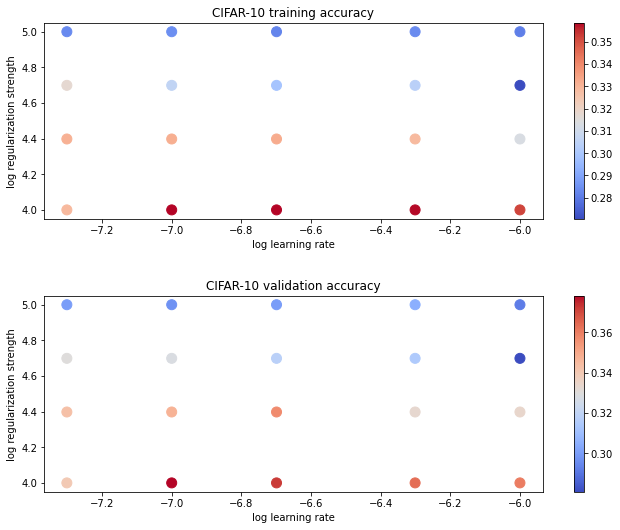

In [20]:
import math

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

marker_size = 100

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
colors = [results[x][0] for x in results]
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel("log learning rate")
plt.ylabel("log regularization strength")
plt.title("CIFAR-10 training accuracy")

plt.subplot(2, 1, 2)
colors = [results[x][1] for x in results]
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel("log learning rate")
plt.ylabel("log regularization strength")
plt.title("CIFAR-10 validation accuracy")

plt.tight_layout(pad=3)
plt.show()


## 14. Final evaluation on the test set

We evaluate the best validation model once on the held-out test set.


In [21]:
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print("Softmax classifier on raw pixels final test set accuracy: %f" % test_accuracy)

best_softmax.save(str(artifacts_dir / "best_softmax.npy"))
print(f"Saved best model to {artifacts_dir / 'best_softmax.npy'}")


Softmax classifier on raw pixels final test set accuracy: 0.362000
/Users/cao20/cao20Lab/reborn/ml-from-scratch/artifacts/best_softmax.npy saved.
Saved best model to /Users/cao20/cao20Lab/reborn/ml-from-scratch/artifacts/best_softmax.npy


## 15. Visualize the learned weights

Each column of the weight matrix can be reshaped back into an image. These visualizations are often interpreted as rough **class templates**.


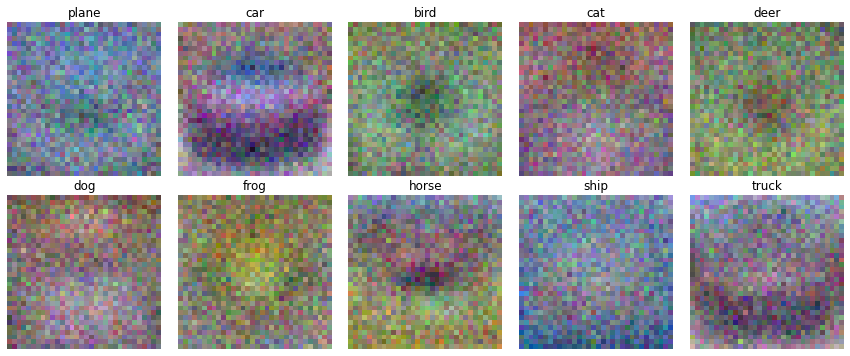

In [22]:
w = best_softmax.W[:-1, :]   # remove the bias row
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)

    wimg = 255.0 * (w[:, :, :, i] - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype("uint8"))
    plt.axis("off")
    plt.title(classes[i])

plt.tight_layout()
plt.show()


### Discussion: what do these weight images mean?

The learned images usually look like blurry, noisy color templates rather than clean objects.

That is expected:
- the classifier is **linear**,
- it works directly on **raw pixels**,
- and each class weight vector is trying to increase the score of one class while decreasing the others.

So each image is not a prototype in the human sense. Instead, it is a map of which pixel patterns push the score up or down for that class. Broad color regions and coarse shape hints often appear, but fine object structure is mostly absent.


## 16. Conceptual checklist

Two final takeaways from the original softmax assignment are worth keeping.

### Why do the learned weights look blurry?
Because each class weight vector is an average linear template in raw-pixel space. Natural images within one class vary a lot in pose, background, lighting, and exact shape, so the learned template becomes diffuse rather than sharp.

### Can a new datapoint change the softmax loss but leave the SVM loss unchanged?
Yes.

If the new datapoint is already classified with a comfortable positive margin, then its multiclass SVM loss is zero, so adding it does not change the total SVM loss.

But the softmax loss is almost never exactly zero, because the softmax still assigns some nonzero probability mass to incorrect classes. So the same datapoint can still contribute a positive amount to the total softmax loss.

This is one of the cleanest conceptual differences between hinge-style losses and probabilistic log-losses.
